# MovieMate

**Project:** Exploring conversational AI for intelligent movie search and recommendations  
**Stack:** TMDB API · Sentence-Transformers · FAISS · Ollama (local LLM) · Gradio

### Setup & Installation

Run the cell below once to install all required packages.  
Then restart the kernel before continuing.

In [1]:
import sys
!{sys.executable} -m pip install -q \
    pandas numpy requests \
    sentence-transformers faiss-cpu \
    gradio matplotlib seaborn tqdm \
    ollama python-dotenv
print("All packages installed.")

All packages installed.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, time, pickle, warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

print("Imports OK.")

Imports OK.


### Configuration

Set your TMDB API key below (get a free one at https://www.themoviedb.org/settings/api).  
Create a .env file with **TMDB_API_KEY=your_key**

In [3]:
from dotenv import load_dotenv
load_dotenv()

TMDB_API_KEY = os.getenv("TMDB_API_KEY", "MY_API_KEY") # replaced my actual API key with a placeholder MY_API_KEY

TMDB_BASE_URL   = "https://api.themoviedb.org/3"
EMBEDDING_MODEL = "all-MiniLM-L6-v2"   
OLLAMA_MODEL    = "llama3.2:3b"            
MOVIES_TO_FETCH = 4000                 
DATA_PATH       = "data/movies.csv"
INDEX_PATH      = "index/faiss_index"
TOP_K           = 10

os.makedirs("data",  exist_ok=True)
os.makedirs("index", exist_ok=True)

if TMDB_API_KEY == "MY_API_KEY":
    print("Please set your TMDB_API_KEY above before proceeding.")
else:
    print(f"TMDB key loaded")

TMDB key loaded


## Data Collection — TMDB API

Movie data pulled from [The Movie Database (TMDB)](https://www.themoviedb.org/).  
The strategy:
1. /genre/movie/list — get all genre IDs  
2. /discover/movie — collect movie IDs balanced across genres  
3. /movie/{id}?append_to_response=credits — one call per movie for full details + cast  

In [121]:
def tmdb_get(endpoint, params=None, retries=3):
    params = params or {}
    params["api_key"] = TMDB_API_KEY
    params.setdefault("language", "en-US")

    for attempt in range(retries):
        try:
            r = requests.get(f"{TMDB_BASE_URL}{endpoint}", params=params, timeout=10)
            r.raise_for_status()
            return r.json()
        except Exception as e:
            if attempt < retries - 1:
                time.sleep(1.5 * (attempt + 1))
            else:
                return None

In [122]:
# discover movie IDs balanced across genres
def discover_movie_ids(total=4000):
    ids_seen, movie_ids = set(), []

    page = 1
    max_pages = 500 

    with tqdm(total=total, desc="Discovering movies") as pbar:
        while len(movie_ids) < total and page <= max_pages:
            data = tmdb_get("/discover/movie", {
                "sort_by": "popularity.desc",
                "vote_count.gte": 50,   
                "page": page
            })

            if not data or "results" not in data:
                page += 1
                continue

            for m in data["results"]:
                if m["id"] not in ids_seen:
                    ids_seen.add(m["id"])
                    movie_ids.append(m["id"])
                    pbar.update(1)

                if len(movie_ids) >= total:
                    break

            page += 1
            time.sleep(0.25)

    return movie_ids

In [14]:
movie_ids = discover_movie_ids(4000)
print(len(movie_ids))

Discovering movies:   0%|          | 0/4000 [00:00<?, ?it/s]

4000


In [15]:
# fetch full details and credits for each movie
def fetch_details(movie_id):
    d = tmdb_get(f"/movie/{movie_id}", {"append_to_response": "credits"})
    if not d:
        return None

    director = next(
        (p["name"] for p in d.get("credits", {}).get("crew", []) if p["job"] == "Director"), ""
    )

    cast = ", ".join(a["name"] for a in d.get("credits", {}).get("cast", [])[:5])
    genres = ", ".join(g["name"] for g in d.get("genres", []))

    release = d.get("release_date", "")
    year = int(release[:4]) if release and len(release) >= 4 else None

    return {
        "id": d.get("id"),
        "title": d.get("title", ""),
        "year": year,
        "genres": genres,
        "vote_average": round(d.get("vote_average", 0.0), 1),
        "vote_count": d.get("vote_count", 0),
        "popularity": round(d.get("popularity", 0.0), 2),
        "runtime": d.get("runtime"),
        "director": director,
        "cast": cast,
        "overview": d.get("overview", ""),
        "original_language": d.get("original_language", ""),
    }

rows = []
fail_count = 0

for mid in tqdm(movie_ids, desc="Fetching movie details"):
    rec = fetch_details(mid)

    if rec and rec["title"] and rec["overview"]:
        rows.append(rec)
    else:
        fail_count += 1

    time.sleep(0.25)

df_raw = pd.DataFrame(rows)
df_raw.to_csv(DATA_PATH, index=False)

print(f"\nSaved: {len(df_raw)} movies")
print(f"Failed/skipped: {fail_count}")

Fetching movie details:   0%|          | 0/4000 [00:00<?, ?it/s]


✅ Saved: 4000 movies
❌ Failed/skipped: 0


### Dataset Exploration

In [4]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}\n")
df.head(5)

Shape: (4000, 12)



,id,title,year,genres,vote_average,vote_count,popularity,runtime,director,cast,overview,original_language
0,83533,Avatar: Fire and Ash,2025,"Science Fiction, Adventure, Fantasy",7.4,2391,485.10,198,James Cameron,"Sam Worthington, Zoe Saldaña, Sigourney Weaver...",In the wake of the devastating war against the...,en
1,1327819,Hoppers,2026,"Animation, Family, Science Fiction, Comedy, Ad...",7.6,395,395.36,105,Daniel Chong,"Piper Curda, Bobby Moynihan, Jon Hamm, Kathy N...",Scientists have discovered how to 'hop' human ...,en
2,1171145,Crime 101,2026,"Crime, Thriller",7.1,516,339.60,141,Bart Layton,"Chris Hemsworth, Mark Ruffalo, Halle Berry, Ba...",When an elusive thief whose high-stakes heists...,en
3,1115544,Mike & Nick & Nick & Alice,2026,"Comedy, Science Fiction, Crime",6.8,178,301.23,107,BenDavid Grabinski,"James Marsden, Vince Vaughn, Eiza González, Ke...",Two gangsters and the woman they love try to s...,en
4,1290821,Shelter,2026,"Action, Crime, Thriller",6.8,489,326.12,107,Ric Roman Waugh,"Jason Statham, Bodhi Rae Breathnach, Michael S...",A man living in self-imposed exile on a remote...,en


In [19]:
print("dtypes & non-null counts")
df.info()

dtypes & non-null counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4000 non-null   int64  
 1   title              4000 non-null   object 
 2   year               4000 non-null   int64  
 3   genres             4000 non-null   object 
 4   vote_average       4000 non-null   float64
 5   vote_count         4000 non-null   int64  
 6   popularity         4000 non-null   float64
 7   runtime            4000 non-null   int64  
 8   director           3999 non-null   object 
 9   cast               3998 non-null   object 
 10  overview           4000 non-null   object 
 11  original_language  4000 non-null   object 
dtypes: float64(2), int64(4), object(6)
memory usage: 375.1+ KB


In [21]:
print("numeric summary")
df[['vote_average', 'popularity', 'runtime']].describe().round(2)

numeric summary


,vote_average,popularity,runtime
count,4000.00,4000.00,4000.00
mean,6.86,9.77,112.38
std,0.75,19.16,23.42
min,3.50,2.61,6.00
25%,6.40,5.05,97.00
50%,6.90,6.33,109.00
75%,7.40,9.15,124.00
max,9.30,485.10,253.00


In [22]:
print("Missing values")
missing = df.isnull().sum()
missing

Missing values


id                   0
title                0
year                 0
genres               0
vote_average         0
vote_count           0
popularity           0
runtime              0
director             1
cast                 2
overview             0
original_language    0
dtype: int64

## Exploratory Data Analysis (EDA)

### Rating Distribution

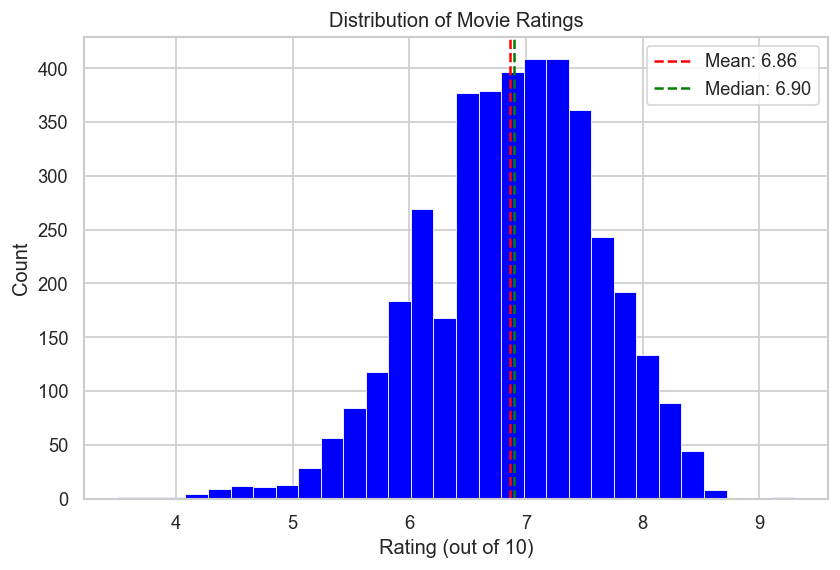

In [123]:
fig, ax = plt.subplots(figsize=(8, 5)) 

# histograph
ax.hist(df["vote_average"].dropna(), bins=30, color="blue", edgecolor="white", linewidth=0.5)
ax.axvline(df["vote_average"].mean(), color="red", linestyle="--", label=f'Mean: {df["vote_average"].mean():.2f}')
ax.axvline(df["vote_average"].median(), color="green", linestyle="--", label=f'Median: {df["vote_average"].median():.2f}')

ax.set_xlabel("Rating (out of 10)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Movie Ratings")
ax.legend()

plt.show()

In [25]:
df['vote_average'].max()

9.3

In [124]:
df.loc[df['vote_average'].idxmax(), 'title'] # highest rated movie

'BTS THE COMEBACK LIVE | ARIRANG'

In [29]:
df['vote_average'].min()

3.5

In [125]:
df.loc[df['vote_average'].idxmin(), 'title'] # lowest rated movie

'Melania'

### Genre Frequency

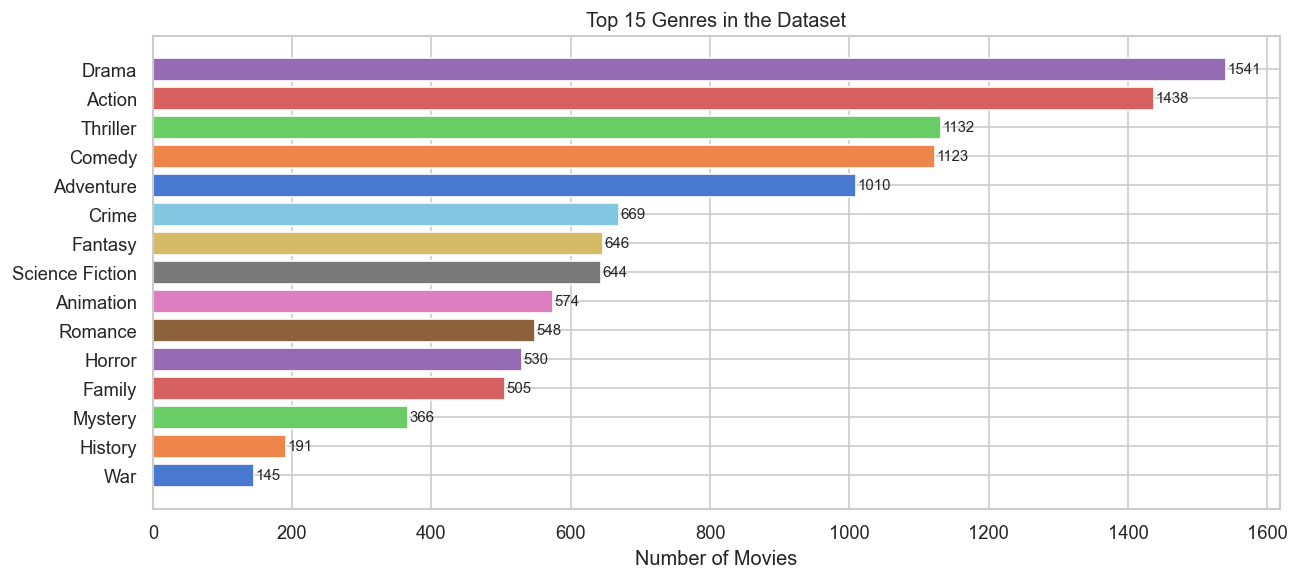

In [126]:
genre_series = df["genres"].dropna().str.split(", ").explode()
genre_counts = genre_series.value_counts()

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(genre_counts.index[:15][::-1], genre_counts.values[:15][::-1],
               color=sns.color_palette("muted", 15))
ax.set_xlabel("Number of Movies")
ax.set_title("Top 15 Genres in the Dataset")
for bar, val in zip(bars, genre_counts.values[:15][::-1]):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2, str(val), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("data/genre_distribution.png", bbox_inches="tight")
plt.show()

### Movies by Release Year

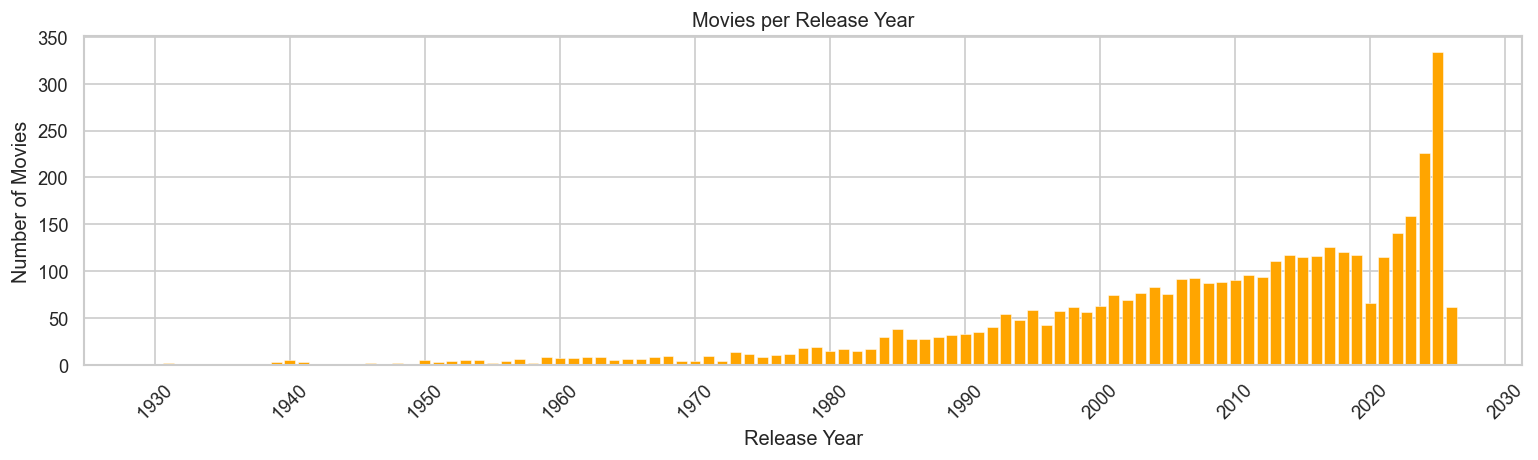

In [107]:
year_counts = df["year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(year_counts.index, year_counts.values, color="orange", edgecolor="white", linewidth=0.3)
ax.set_xlabel("Release Year")
ax.set_ylabel("Number of Movies")
ax.set_title("Movies per Release Year")
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("data/year_distribution.png", bbox_inches="tight")
plt.show()

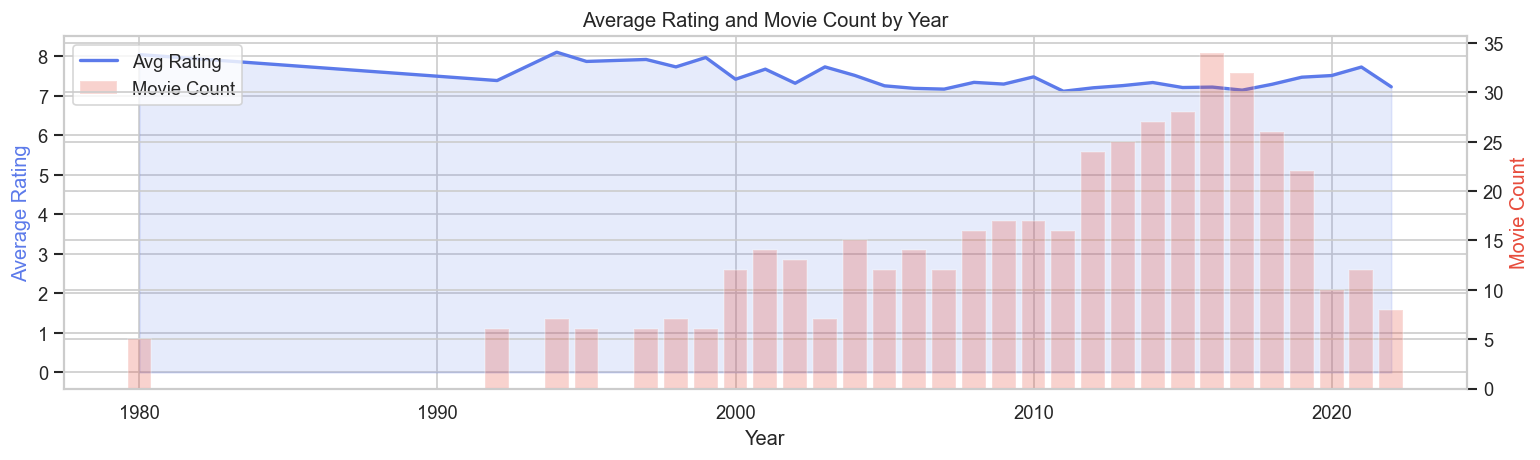

In [14]:
avg_by_year = df.groupby("year")["vote_average"].agg(["mean", "count"])
avg_by_year = avg_by_year[avg_by_year["count"] >= 5]  # only years with enough data

fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()

ax1.plot(avg_by_year.index, avg_by_year["mean"], color="#5C7AEA", linewidth=2, label="Avg Rating")
ax1.fill_between(avg_by_year.index, avg_by_year["mean"], alpha=0.15, color="#5C7AEA")
ax2.bar(avg_by_year.index, avg_by_year["count"], alpha=0.25, color="#E74C3C", label="Movie Count")

ax1.set_xlabel("Year")
ax1.set_ylabel("Average Rating", color="#5C7AEA")
ax2.set_ylabel("Movie Count", color="#E74C3C")
ax1.set_title("Average Rating and Movie Count by Year")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.savefig("data/rating_trend.png", bbox_inches="tight")
plt.show()


### Top Directors

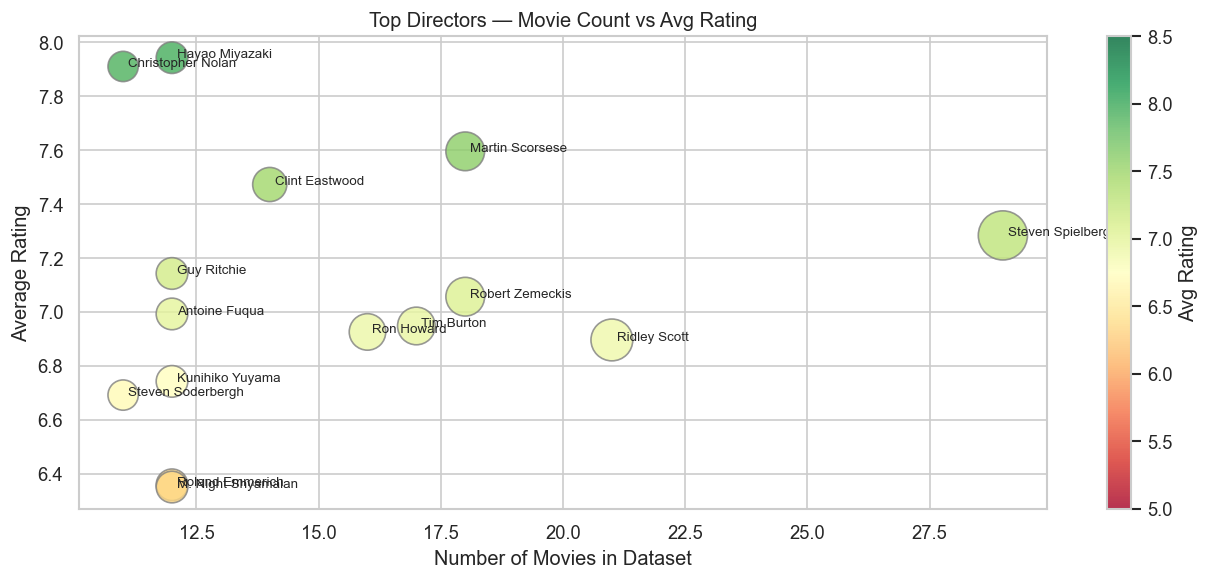

Top 10 directors by movie count:
                  movies  avg_rating
director                            
Steven Spielberg      29    7.282759
Ridley Scott          21    6.895238
Robert Zemeckis       18    7.055556
Martin Scorsese       18    7.594444
Tim Burton            17    6.947059
Ron Howard            16    6.925000
Clint Eastwood        14    7.471429
Hayao Miyazaki        12    7.941667
Antoine Fuqua         12    6.991667
Roland Emmerich       12    6.358333


In [40]:
top_directors = (
    df[df["director"] != ""]
    .groupby("director")
    .agg(movies=("title", "count"), avg_rating=("vote_average", "mean"))
    .query("movies >= 3")
    .sort_values("movies", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(11, 5))
scatter = ax.scatter(
    top_directors["movies"],
    top_directors["avg_rating"],
    s=top_directors["movies"] * 30,
    c=top_directors["avg_rating"],
    cmap="RdYlGn", vmin=5, vmax=8.5, alpha=0.8, edgecolors="grey"
)
for _, row in top_directors.iterrows():
    ax.annotate(row.name, (row["movies"] + 0.1, row["avg_rating"]), fontsize=8)
plt.colorbar(scatter, label="Avg Rating")
ax.set_xlabel("Number of Movies in Dataset")
ax.set_ylabel("Average Rating")
ax.set_title("Top Directors — Movie Count vs Avg Rating")
plt.tight_layout()
plt.savefig("data/top_directors.png", bbox_inches="tight")
plt.show()

print("Top 10 directors by movie count:")
print(top_directors.head(10).to_string())


### Runtime Distribution

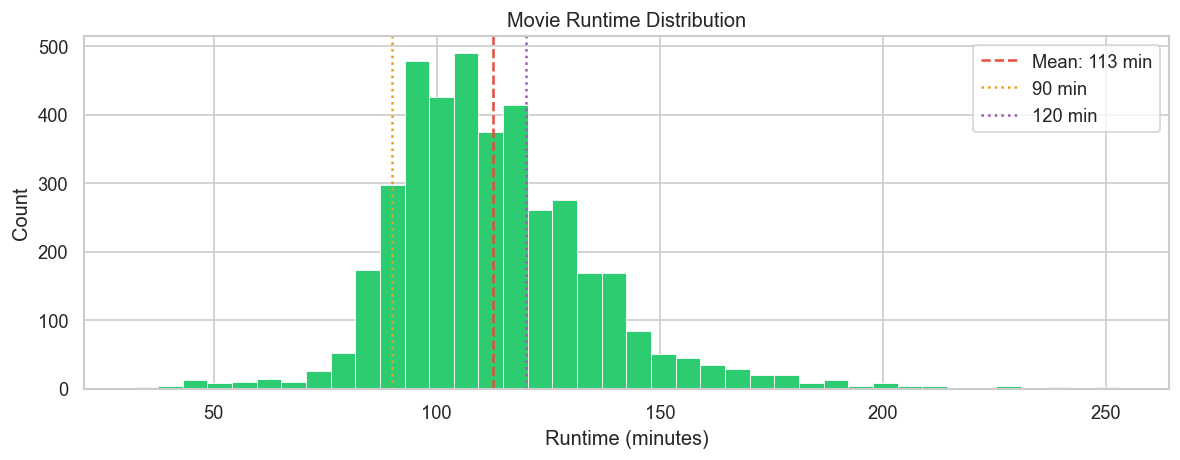

In [43]:
runtime_clean = df["runtime"].dropna()
runtime_clean = runtime_clean[(runtime_clean > 30) & (runtime_clean < 300)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(runtime_clean, bins=40, color="#2ECC71", edgecolor="white", linewidth=0.5)
ax.axvline(runtime_clean.mean(), color="#E74C3C", linestyle="--", label=f"Mean: {runtime_clean.mean():.0f} min")
ax.axvline(90,  color="#F39C12", linestyle=":", label="90 min")
ax.axvline(120, color="#9B59B6", linestyle=":", label="120 min")
ax.set_xlabel("Runtime (minutes)")
ax.set_ylabel("Count")
ax.set_title("Movie Runtime Distribution")
ax.legend()
plt.tight_layout()
plt.savefig("data/runtime_distribution.png", bbox_inches="tight")
plt.show()


### Rating vs Vote Count (Popularity vs Quality)

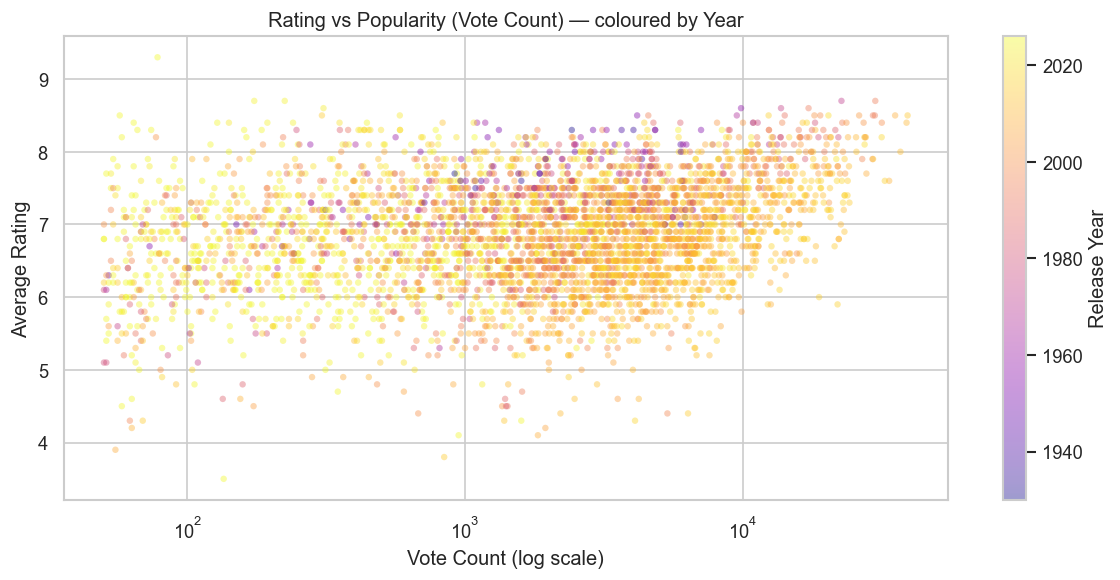

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(
    df["vote_count"], df["vote_average"],
    c=df["year"], cmap="plasma",
    alpha=0.4, s=15, linewidths=0
)
plt.colorbar(sc, label="Release Year")
ax.set_xscale("log")
ax.set_xlabel("Vote Count (log scale)")
ax.set_ylabel("Average Rating")
ax.set_title("Rating vs Popularity (Vote Count) — coloured by Year")
plt.tight_layout()
plt.savefig("data/rating_vs_votes.png", bbox_inches="tight")
plt.show()


## Data Preprocessing

In [45]:
print(f"Before cleaning: {len(df)} rows")

Before cleaning: 4000 rows


In [46]:
# drop rows missing critical fields

df = df.dropna(subset=["title", "year", "genres"]) # if the row is missing any of these, drop it
df = df[df["overview"].str.len() > 20] # if the overview is longer than 20 characters, keep it
df = df[df["genres"].str.len() > 0] # if the genre of the film is missing, drop it

In [47]:
# type coercions - forces a 'bad value' to NaN (Not a Number), then converts to a certain type
df["year"]          = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df["vote_average"]  = pd.to_numeric(df["vote_average"], errors="coerce").fillna(0.0)
df["vote_count"]    = pd.to_numeric(df["vote_count"], errors="coerce").fillna(0).astype(int)
df["runtime"]       = pd.to_numeric(df["runtime"], errors="coerce")

In [48]:
# filling missing text fields (fields which were not dropped in case of missing values)
df["director"] = df["director"].fillna("").str.strip()
df["cast"]     = df["cast"].fillna("").str.strip()
df["overview"] = df["overview"].fillna("").str.strip()

In [49]:
df = df.drop_duplicates(subset=["id"]).reset_index(drop=True)

In [50]:
# save cleaned version
df.to_csv(DATA_PATH, index=False)
print(f"After cleaning:  {len(df)} rows")
df[["title","year","genres","vote_average","director","runtime"]].head(8)

After cleaning:  4000 rows


,title,year,genres,vote_average,director,runtime
0,Avatar: Fire and Ash,2025,"Science Fiction, Adventure, Fantasy",7.4,James Cameron,198
1,Hoppers,2026,"Animation, Family, Science Fiction, Comedy, Ad...",7.6,Daniel Chong,105
2,Crime 101,2026,"Crime, Thriller",7.1,Bart Layton,141
3,Mike & Nick & Nick & Alice,2026,"Comedy, Science Fiction, Crime",6.8,BenDavid Grabinski,107
4,Shelter,2026,"Action, Crime, Thriller",6.8,Ric Roman Waugh,107
5,The Super Mario Galaxy Movie,2026,"Animation, Adventure, Fantasy, Family, Comedy",7.0,Michael Jelenic,98
6,Pretty Lethal,2026,"Music, Thriller, Action, Horror",6.9,Vicky Jewson,89
7,GOAT,2026,"Animation, Comedy, Family",7.9,Tyree Dillihay,100


In [113]:
df['title'].nunique()

3890

In [114]:
df['title'].duplicated().sum() 

110

In [109]:
duplicate_count = df.duplicated(subset=['title', 'director', 'year']).sum()
duplicate_count

0

There are 110 movies whose titles are not unique.  
But none of their directors or year of release matches.  
So they are different movies with same title.

In [112]:
main_columns = ['title', 'director', 'year']
df[df['title'].isin(repeated_values)].sort_values("title")[main_columns]

,title,director,year
3673,12 Angry Men,William Friedkin,1997
252,12 Angry Men,Sidney Lumet,1957
3087,3:10 to Yuma,James Mangold,2007
3840,3:10 to Yuma,Delmer Daves,1957
679,A Nightmare on Elm Street,Wes Craven,1984
...,...,...,...
3751,West Side Story,Jerome Robbins,1961
894,Wrong Turn,Rob Schmidt,2003
1392,Wrong Turn,Mike P. Nelson,2021
3053,Wuthering Heights,Peter Kosminsky,1992


In [115]:
print(f"\nYear range: {df['year'].min()} – {df['year'].max()}")
print(f"Rating range: {df['vote_average'].min()} – {df['vote_average'].max()}")
print(f"Unique genres: {df['genres'].str.split(', ').explode().nunique()}")
print(f"Unique directors: {df['director'][df['director']!=''].nunique()}")


Year range: 1930 – 2026
Rating range: 3.5 – 9.3
Unique genres: 19
Unique directors: 1985


### Metadata filtering 

In [60]:
def filter_movies(
    df,
    min_year=None,
    max_year=None,
    min_rating=None,
    max_rating=None,
    genre=None,
    language=None,
    min_runtime=None,
    max_runtime=None,
):
    filtered = df.copy()

    if min_year is not None:
        filtered = filtered[filtered["year"] >= min_year]

    if max_year is not None:
        filtered = filtered[filtered["year"] <= max_year]

    if min_rating is not None:
        filtered = filtered[filtered["vote_average"] >= min_rating]

    if max_rating is not None:
        filtered = filtered[filtered["vote_average"] <= max_rating]

    if genre:
        filtered = filtered[
            filtered["genres"].str.contains(genre, case=False, na=False)
        ]

    if language:
        filtered = filtered[
            filtered["original_language"].str.lower() == language.lower()
        ]

    if min_runtime is not None:
        filtered = filtered[filtered["runtime"] >= min_runtime]

    if max_runtime is not None:
        filtered = filtered[filtered["runtime"] <= max_runtime]

    return filtered.reset_index(drop=True)

In [65]:
# example
filtered_df = filter_movies(
    df,
    min_year=2015,
    max_year=2015,
    min_rating=7.5,
    genre="Action"
)

print(len(filtered_df))
filtered_df.head()

4


,id,title,year,genres,vote_average,vote_count,popularity,runtime,director,cast,overview,original_language
0,76341,Mad Max: Fury Road,2015,"Action, Adventure, Science Fiction",7.6,23909,22.83,121,George Miller,"Tom Hardy, Charlize Theron, Nicholas Hoult, Hu...",An apocalyptic story set in the furthest reach...,en
1,207703,Kingsman: The Secret Service,2015,"Crime, Comedy, Action, Adventure",7.6,17698,9.08,129,Matthew Vaughn,"Taron Egerton, Colin Firth, Samuel L. Jackson,...",The story of a super-secret spy organization t...,en
2,315465,The Boy and the Beast,2015,"Action, Adventure, Animation, Drama, Family, F...",7.9,1585,5.47,119,Mamoru Hosoda,"Koji Yakusho, Aoi Miyazaki, Shota Sometani, Su...","Kyuta, a boy living in Shibuya, and Kumatetsu,...",ja
3,256040,Bāhubali: The Beginning,2015,"Action, Drama",7.5,914,5.26,159,S. S. Rajamouli,"Prabhas, Rana Daggubati, Tamannaah Bhatia, Anu...",The young Shivudu is left as a foundling in a ...,te


In [66]:
# example
filtered_df = filter_movies(
    df,
    genre="Comedy",
    max_runtime=120
)
print(len(filtered_df))
filtered_df.head()

973


,id,title,year,genres,vote_average,vote_count,popularity,runtime,director,cast,overview,original_language
0,1327819,Hoppers,2026,"Animation, Family, Science Fiction, Comedy, Ad...",7.6,395,395.36,105,Daniel Chong,"Piper Curda, Bobby Moynihan, Jon Hamm, Kathy N...",Scientists have discovered how to 'hop' human ...,en
1,1115544,Mike & Nick & Nick & Alice,2026,"Comedy, Science Fiction, Crime",6.8,178,301.23,107,BenDavid Grabinski,"James Marsden, Vince Vaughn, Eiza González, Ke...",Two gangsters and the woman they love try to s...,en
2,1226863,The Super Mario Galaxy Movie,2026,"Animation, Adventure, Fantasy, Family, Comedy",7.0,268,317.09,98,Michael Jelenic,"Chris Pratt, Charlie Day, Anya Taylor-Joy, Jac...",Having thwarted Bowser's previous plot to marr...,en
3,1297842,GOAT,2026,"Animation, Comedy, Family",7.9,334,252.75,100,Tyree Dillihay,"Caleb McLaughlin, Gabrielle Union, Stephen Cur...",A small goat with big dreams gets a once-in-a-...,en
4,502356,The Super Mario Bros. Movie,2023,"Family, Comedy, Adventure, Animation, Fantasy",7.6,10439,225.70,93,Aaron Horvath,"Chris Pratt, Anya Taylor-Joy, Charlie Day, Jac...","While working underground to fix a water main,...",en


## Embedding & Vector Indexing
FAISS (Facebook AI Similarity Search) performs exact or approximate nearest-neighbour search in high-dimensional spaces.

In [5]:
def build_movie_document(row):
    """Convert a movie row to a natural-language document for embedding."""
    parts = [f"Title: {row['title']}."]
    if pd.notna(row.get("year")):
        parts.append(f"Released: {int(row['year'])}.")
    if row.get("genres"):
        parts.append(f"Genres: {row['genres']}.")
    if row.get("vote_average", 0) > 0:
        parts.append(f"Rating: {row['vote_average']:.1f}/10.")
    if row.get("director"):
        parts.append(f"Directed by {row['director']}.")
    if row.get("cast"):
        parts.append(f"Starring: {row['cast']}.")
    if pd.notna(row.get("runtime")) and row["runtime"] > 0:
        parts.append(f"Runtime: {int(row['runtime'])} minutes.")
    if row.get("overview"):
        parts.append(f"Plot: {str(row['overview'])[:400]}")
    return " ".join(parts)

In [6]:
docs = [build_movie_document(row) for _, row in df.iterrows()]
print(f"Built {len(docs)} documents. Sample:\n")
print(docs[0])

Built 4000 documents. Sample:

Title: Avatar: Fire and Ash. Released: 2025. Genres: Science Fiction, Adventure, Fantasy. Rating: 7.4/10. Directed by James Cameron. Starring: Sam Worthington, Zoe Saldaña, Sigourney Weaver, Stephen Lang, Oona Chaplin. Runtime: 198 minutes. Plot: In the wake of the devastating war against the RDA and the loss of their eldest son, Jake Sully and Neytiri face a new threat on Pandora: the Ash People, a violent and power-hungry Na'vi tribe led by the ruthless Varang. Jake's family must fight for their survival and the future of Pandora in a conflict that pushes them to their emotional and physical limits.


In [7]:
from sentence_transformers import SentenceTransformer
import faiss

print(f"Loading embedding model: all-MiniLM-L6-v2")

embedder = SentenceTransformer("all-MiniLM-L6-v2")

print("Encoding movies …")
embeddings = embedder.encode(
    docs,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
).astype(np.float32)

print(f"\nEmbedding shape: {embeddings.shape}")


Loading embedding model: all-MiniLM-L6-v2
Encoding movies …


Batches:   0%|          | 0/63 [00:00<?, ?it/s]


Embedding shape: (4000, 384)


In [8]:
faiss.normalize_L2(embeddings) # vector -> unit vector

dim   = embeddings.shape[1]
index = faiss.IndexFlatIP(dim) # identical to cosine similarity (since embeddings are normalized)
index.add(embeddings)

print(f"FAISS index: {index.ntotal} vectors | dim = {dim}")

# .faiss -> handles fast searching 
# .pkl -> maps row numbers to movie titles
faiss.write_index(index, INDEX_PATH + ".faiss")
with open(INDEX_PATH + ".pkl", "wb") as f:
    pickle.dump(docs, f)

print(f"\nSaved → {INDEX_PATH}.faiss  &  {INDEX_PATH}.pkl")


FAISS index: 4000 vectors | dim = 384

Saved → index/faiss_index.faiss  &  index/faiss_index.pkl


In [9]:
def retrieve(query, top_k=50):
    q_emb = embedder.encode([query], convert_to_numpy=True).astype(np.float32)
    faiss.normalize_L2(q_emb)

    distances, indices = index.search(q_emb, top_k)

    results = []
    for dist, idx in zip(distances[0], indices[0]):
        if 0 <= idx < len(df):
            row = df.iloc[idx].to_dict()
            row["_score"] = float(dist)
            results.append(row)

    return results

### Metadata filtering 

In [10]:
def apply_metadata_filters(results, min_year=None, genre=None, min_rating=None):
    filtered = []

    for r in results:
        if min_year and (not r.get("year") or r["year"] < min_year):
            continue

        if min_rating and r.get("vote_average", 0) < min_rating:
            continue

        if genre and genre.lower() not in str(r.get("genres", "")).lower():
            continue

        filtered.append(r)

    return filtered

### Re-ranking

In [11]:
from sentence_transformers import CrossEncoder

cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def rerank(query, results):
    pairs = [
        (query, r["title"] + " " + r["overview"])
        for r in results
    ]

    scores = cross_encoder.predict(pairs)

    for r, score in zip(results, scores):
        r["_rerank_score"] = float(score)

    return sorted(results, key=lambda x: x["_rerank_score"], reverse=True)

In [12]:
def search(query, top_k=5, min_year=None, genre=None, min_rating=None):
    # retrieve more candidates
    candidates = retrieve(query, top_k=50)

    # filter
    filtered = apply_metadata_filters(
        candidates,
        min_year=min_year,
        genre=genre,
        min_rating=min_rating
    )

    # re-rank
    reranked = rerank(query, filtered)

    # return final top_k
    return reranked[:top_k]

In [13]:
# example
results = search("space travel", top_k=5)

for r in results:
    print(f"{r['title']} ({r['year']}) | {r['vote_average']} | Score: {r['_score']:.3f}")

Paul (2011) | 6.7 | Score: 0.298
Interstellar (2014) | 8.5 | Score: 0.400
Passengers (2016) | 7.0 | Score: 0.411
Project Gemini (2022) | 5.7 | Score: 0.431
Asteroid City (2023) | 6.4 | Score: 0.296


In [14]:
results = retrieve("space travel", top_k=10)

for r in results:
    print(f"{r['title']} | FAISS Score: {r['_score']:.3f}")

Project Gemini | FAISS Score: 0.431
Spaceballs | FAISS Score: 0.427
The Right Stuff | FAISS Score: 0.415
Explorers | FAISS Score: 0.413
Passengers | FAISS Score: 0.411
The Astronaut | FAISS Score: 0.407
Lost in Space | FAISS Score: 0.401
Interstellar | FAISS Score: 0.400
Gravity | FAISS Score: 0.396
Spaceman | FAISS Score: 0.382


In [50]:
reranked = rerank("space travel", results)

for r in reranked[:5]:
    print(f"{r['title']} | Final Score: {r['_rerank_score']}")

Interstellar | Final Score: 0.8661883473396301
Passengers | Final Score: 0.5480057597160339
Project Gemini | Final Score: -2.973788022994995
Spaceman | Final Score: -3.4865283966064453
Gravity | Final Score: -3.5087404251098633


In [51]:
results = search("batman dark knight joker", top_k=5)

for r in results:
    print(r["title"])

The Dark Knight
The Dark Knight Rises
Batman
Joker
Batman Begins


## Chatbot Demo 

Install Ollama from https://ollama.com

In terminal,  
**ollama pull llama3.2:3b** (or any other model based on available compute power) 

### Terminal

In [52]:
import ollama

# verify Ollama is running 
try:
    models = ollama.list()
    available = [m.model for m in models.models]
    print(f"Ollama running | Available models: {available}")
    if OLLAMA_MODEL not in available:
        print(f"\n Model '{OLLAMA_MODEL}' not found.")
        print(f"Run in terminal:  ollama pull {OLLAMA_MODEL}")
except Exception as e:
    print(f"Cannot reach Ollama: {e}")
    print("Start Ollama: open the Ollama app or run 'ollama serve' in terminal.")

Ollama running | Available models: ['llama3.2:latest', 'llama3.2:3b', 'llama3.2:1b', 'mistral:latest', 'phi3:latest', 'qwen2.5:1.5b', 'qwen2.5vl:3b', 'qwen2.5:3b-instruct']


In [53]:
SYSTEM_PROMPT = """You are MovieMate, a friendly and knowledgeable movie recommendation assistant.
You have access to a curated movie database. For every user message you receive retrieved movie data
from that database — use it as the factual basis for your response.

Rules:
- Base recommendations on the retrieved movies provided; do not invent titles.
- Be warm, conversational, and concise (short intro, then bullet points for movies).
- Always include the movie title and year, and highlight one compelling reason to watch each.
- Support follow-up questions: the user may refine (e.g. 'only those after 2010').
"""

In [54]:
def format_context(movies):
    lines = []

    for i, m in enumerate(movies, 1):
        yr      = int(m["year"]) if pd.notna(m.get("year")) else "N/A"
        rating  = f"{m['vote_average']:.1f}" if pd.notna(m.get("vote_average")) else "N/A"
        runtime = f"{int(m['runtime'])} min" if pd.notna(m.get("runtime")) and m["runtime"] > 0 else "N/A"

        score   = f"{m.get('_score', 0):.3f}"
        rerank  = f"{m.get('_rerank_score', 0):.3f}" if "_rerank_score" in m else "N/A"

        lines.append(f"{i}. {m['title']} ({yr})")
        lines.append(f"Rating: {rating}/10  |  Runtime: {runtime}")
        lines.append(f"Genre: {m.get('genres','N/A')}")
        lines.append(f"Scores → FAISS: {score} | Rerank: {rerank}")

        if m.get("director"):
            lines.append(f"Director: {m['director']}")

        if m.get("cast"):
            lines.append(f"Stars: {m['cast']}")

        if m.get("overview"):
            lines.append(f"Plot: {str(m['overview'])[:250]}…")

        lines.append("")

    return "\n".join(lines)

In [57]:
history = []

def chat(user_message, verbose=True, **filters):
    # full pipeline (retrieve + filter + rerank)
    movies = search(user_message, top_k=5, **filters)

    # format context
    context = format_context(movies)

    # build augmented prompt
    augmented = (
        f'User query: "{user_message}"\n\n'
        f"Retrieved movies from the database:\n{context}\n"
        "Please respond to the user's query using these movies."
    )

    history.append({"role": "user", "content": augmented})

    # LLM call
    response = ollama.chat(
        model=OLLAMA_MODEL,
        messages=[{"role": "system", "content": SYSTEM_PROMPT}] + history[-12:],
    )

    reply = response["message"]["content"]
    history.append({"role": "assistant", "content": reply})

    if verbose:
        print(f"\n{'─'*60}")
        print(f"You: {user_message}")
        print(f"\nMovieMate:\n{reply}")
        print(f"{'─'*60}")

In [56]:
chat("Suggest some great science fiction movies")


────────────────────────────────────────────────────────────
You: Suggest some great science fiction movies

MovieMate:
Science Fiction Fans Rejoice!

Here are some fantastic science fiction movie recommendations for you:

• **Evolution (2001) - 6.1/10**: This comedy takes a humorous approach to the concept of evolution and survival, with a dash of sci-fi action. Why watch? It's a fun, lighthearted film that explores what happens when aliens invade Earth.

• **Victor Frankenstein (2015) - 5.9/10**: A darker, more introspective take on the classic tale, this movie delves into the complexities of creation and responsibility. Why watch? It's a thought-provoking exploration of ethics and human nature.

• **Fantastic Four (2005) - 5.8/10**: Although it received mixed reviews, this superhero sci-fi film has its moments. Why watch? The visual effects are impressive, especially for its time, and the characters' powers make for entertaining action sequences.

• **Alien: Romulus (2024) - 7.2/10

"Science Fiction Fans Rejoice!\n\nHere are some fantastic science fiction movie recommendations for you:\n\n• **Evolution (2001) - 6.1/10**: This comedy takes a humorous approach to the concept of evolution and survival, with a dash of sci-fi action. Why watch? It's a fun, lighthearted film that explores what happens when aliens invade Earth.\n\n• **Victor Frankenstein (2015) - 5.9/10**: A darker, more introspective take on the classic tale, this movie delves into the complexities of creation and responsibility. Why watch? It's a thought-provoking exploration of ethics and human nature.\n\n• **Fantastic Four (2005) - 5.8/10**: Although it received mixed reviews, this superhero sci-fi film has its moments. Why watch? The visual effects are impressive, especially for its time, and the characters' powers make for entertaining action sequences.\n\n• **Alien: Romulus (2024) - 7.2/10**: A recent release with a gripping premise, this horror-tinged sci-fi film will keep you on the edge of your

In [58]:
chat("What about Christopher Nolan films?")


────────────────────────────────────────────────────────────
You: What about Christopher Nolan films?

MovieMate:
Christopher Nolan isn't among those retrieved films, but let me suggest some notable directors you might enjoy:

* If you like Quentin Tarantino (Pulp Fiction), consider:
	+ Inglourious Basterds (2009) - a WWII action film with Tarantino's signature style.
	+ Kill Bill: Vol. 1 (2003) - an epic martial arts anime-inspired revenge tale.
* If you prefer Peter Jackson (King Kong), try:
	+ The Lord of the Rings: The Fellowship of the Ring (2001) - the first installment in Jackson's iconic fantasy trilogy.

These directors are known for crafting engaging stories and memorable characters, which might appeal to fans of Nolan or his contemporaries.
────────────────────────────────────────────────────────────


In [59]:
chat("What is the one common thing between Seven, Fight Club, Zodiac and The Social Network.")


────────────────────────────────────────────────────────────
You: What is the one common thing between Seven, Fight Club, Zodiac and The Social Network.

MovieMate:
It looks like there might be a mix-up! None of the retrieved movies seem to have any direct connection with each other, except for one key detail: all of them were directed by David Fincher.

If that's not what you're looking for, I'm happy to try again or provide more information about the retrieved films. However, if you'd like to explore more films in a similar vein (drama, thriller, mystery), here are some suggestions:

* If you enjoy complex characters and intricate storylines:
	+ Gone Girl (2014) - a twisted psychological thriller.
	+ Shutter Island (2010) - a mind-bending mystery set in the 1950s.
* If you prefer films that explore themes of obsession or the darker side of human nature:
	+ The Silence of the Lambs (1991) - a chilling serial killer drama.
	+ Memento (2000) - a critically acclaimed thriller about memo

### UI

In [60]:
import gradio as gr
import ollama

def extract_text(content):
    """Ensures content is a string, even if Gradio sends a list/dict."""
    if isinstance(content, list):
        return " ".join([item.get("text", "") for item in content if isinstance(item, dict)])
    return str(content)

def movie_chat(user_input, chat_history):
    try:
        messages = [{"role": "system", "content": SYSTEM_PROMPT}]

        # add history
        for turn in chat_history:
            if isinstance(turn, dict):
                role = turn.get('role')
                content = extract_text(turn.get('content', ''))
                messages.append({"role": role, "content": content})

            elif isinstance(turn, (list, tuple)) and len(turn) == 2:
                user_msg, bot_msg = turn
                if user_msg:
                    messages.append({"role": "user", "content": extract_text(user_msg)})
                if bot_msg:
                    messages.append({"role": "assistant", "content": extract_text(bot_msg)})

        # process current query
        raw_query = extract_text(user_input)

        found_movies = search(raw_query, top_k=5)

        # optional fallback
        if not found_movies:
            found_movies = retrieve(raw_query, top_k=5)

        movie_details = format_context(found_movies)

        final_query = (
            f"User Query: {raw_query}\n\n"
            f"Retrieved Movies:\n{movie_details}\n\n"
            "Answer the user's query using these results."
        )

        messages.append({"role": "user", "content": final_query})

        # stream response
        response_text = ""
        stream = ollama.chat(model=OLLAMA_MODEL, messages=messages, stream=True)

        for chunk in stream:
            if 'message' in chunk and 'content' in chunk['message']:
                content = chunk['message']['content']
                response_text += content
                yield response_text

    except Exception as e:
        yield f"System Error: {str(e)}"

# UI Setup 
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# MovieMate")
    
    gr.ChatInterface(
        fn=movie_chat,
        examples=["Find me 90s action movies", "Suggest something like Inception"],
        cache_examples=False,
    )

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://e65fd4c36d3a9bc09b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
